In [1]:
# LOAD & INSPECT

import pandas as pd

# Load climate data
rain_df = pd.read_excel(
    r"C:\Users\LENOVO\OneDrive\Documents\PhD_MsC_FECourses\AGNESS\capstone\era5-x0.25_timeseries_tas,hd30,cdd_Precipitation_timeseries_annual_1950-2023_mean_historical_era5_x0.25_mean.xlsx"
)

print("=== CLIMATE DATA ===")
print(rain_df.head())
print("\nColumns:")
print(rain_df.columns)
print("\nShape:", rain_df.shape)


# Load yield data
yield_df = pd.read_csv(
    r"C:\Users\LENOVO\OneDrive\Documents\PhD_MsC_FECourses\AGNESS\capstone\FAOSTAT_data_en_3-22-2026.csv"
)

print("\n=== YIELD DATA ===")
print(yield_df.head())
print("\nColumns:")
print(yield_df.columns)
print("\nShape:", yield_df.shape)

=== CLIMATE DATA ===
   Unnamed: 0  Unnamed: 1  Unnamed: 2  Unnamed: 3  Unnamed: 4  Unnamed: 5  \
0         NaN         NaN         NaN         NaN         NaN         NaN   
1         NaN         NaN         NaN         NaN         NaN         NaN   
2         NaN         NaN         NaN         NaN         NaN         NaN   
3         NaN         NaN         NaN         NaN         NaN         NaN   
4         NaN         NaN         NaN         NaN         NaN         NaN   

   Unnamed: 6  Unnamed: 7  Unnamed: 8  Unnamed: 9  ...  Unnamed: 58  \
0         NaN         NaN         NaN         NaN  ...          NaN   
1         NaN         NaN         NaN         NaN  ...          NaN   
2         NaN         NaN         NaN         NaN  ...          NaN   
3         NaN         NaN         NaN         NaN  ...          NaN   
4         NaN         NaN         NaN         NaN  ...          NaN   

   Unnamed: 59  Unnamed: 60  Unnamed: 61  Unnamed: 62  Year    cdd    hd30  \
0          

In [2]:
# CLEAN CLIMATE DATA

# Keep only useful columns
rain_df = rain_df[['Year', 'Precipitation', 'cdd', 'hd30', 'tas']].copy()

# Rename columns
rain_df.columns = ['year', 'rainfall', 'cdd', 'hd30', 'tas']

# Convert to numeric
for col in ['rainfall', 'cdd', 'hd30', 'tas']:
    rain_df[col] = pd.to_numeric(rain_df[col], errors='coerce')

# Drop missing values
rain_df = rain_df.dropna()

# Filter period
rain_df = rain_df[(rain_df['year'] >= 1961) & (rain_df['year'] <= 2023)]

print("Clean climate data:")
print(rain_df.head())
print(rain_df.describe())

Clean climate data:
    year  rainfall    cdd    hd30    tas
11  1961    960.87  68.17  252.57  26.09
12  1962   1389.65  60.04  223.54  25.76
13  1963   1407.09  48.26  245.57  26.03
14  1964   1037.64  56.72  245.06  26.23
15  1965   1301.80  52.54  242.98  25.95
              year     rainfall        cdd        hd30        tas
count    63.000000    63.000000  63.000000   63.000000  63.000000
mean   1992.000000  1336.071905  48.701746  256.964603  26.640476
std      18.330303   154.917158   8.795605   19.049667   0.524203
min    1961.000000   960.870000  32.010000  209.660000  25.590000
25%    1976.500000  1240.415000  43.365000  246.000000  26.290000
50%    1992.000000  1356.920000  48.010000  258.390000  26.660000
75%    2007.500000  1443.300000  54.360000  269.090000  26.995000
max    2023.000000  1737.460000  70.360000  303.320000  27.750000


In [3]:
# CLEAN YIELD DATA

yield_df = yield_df[['Year', 'Value']].copy()

yield_df.columns = ['year', 'yield']

yield_df['yield'] = pd.to_numeric(yield_df['yield'], errors='coerce')

yield_df = yield_df.dropna()

yield_df = yield_df[(yield_df['year'] >= 1961) & (yield_df['year'] <= 2023)]

print("\nClean yield data:")
print(yield_df.head())


Clean yield data:
   year  yield
0  1961  492.6
1  1962  604.7
2  1963  475.9
3  1964  440.0
4  1965  425.4


In [4]:
# MERGE DATA

data = pd.merge(rain_df, yield_df, on='year')

print("\nMerged data:")
print(data.head())
print(data.describe())


Merged data:
   year  rainfall    cdd    hd30    tas  yield
0  1961    960.87  68.17  252.57  26.09  492.6
1  1962   1389.65  60.04  223.54  25.76  604.7
2  1963   1407.09  48.26  245.57  26.03  475.9
3  1964   1037.64  56.72  245.06  26.23  440.0
4  1965   1301.80  52.54  242.98  25.95  425.4
              year     rainfall        cdd        hd30        tas        yield
count    63.000000    63.000000  63.000000   63.000000  63.000000    63.000000
mean   1992.000000  1336.071905  48.701746  256.964603  26.640476  1015.920635
std      18.330303   154.917158   8.795605   19.049667   0.524203   253.733430
min    1961.000000   960.870000  32.010000  209.660000  25.590000   425.400000
25%    1976.500000  1240.415000  43.365000  246.000000  26.290000   888.600000
50%    1992.000000  1356.920000  48.010000  258.390000  26.660000  1111.500000
75%    2007.500000  1443.300000  54.360000  269.090000  26.995000  1213.300000
max    2023.000000  1737.460000  70.360000  303.320000  27.750000  1389.

In [5]:
print(data.head())
print(data.describe())

   year  rainfall    cdd    hd30    tas  yield
0  1961    960.87  68.17  252.57  26.09  492.6
1  1962   1389.65  60.04  223.54  25.76  604.7
2  1963   1407.09  48.26  245.57  26.03  475.9
3  1964   1037.64  56.72  245.06  26.23  440.0
4  1965   1301.80  52.54  242.98  25.95  425.4
              year     rainfall        cdd        hd30        tas        yield
count    63.000000    63.000000  63.000000   63.000000  63.000000    63.000000
mean   1992.000000  1336.071905  48.701746  256.964603  26.640476  1015.920635
std      18.330303   154.917158   8.795605   19.049667   0.524203   253.733430
min    1961.000000   960.870000  32.010000  209.660000  25.590000   425.400000
25%    1976.500000  1240.415000  43.365000  246.000000  26.290000   888.600000
50%    1992.000000  1356.920000  48.010000  258.390000  26.660000  1111.500000
75%    2007.500000  1443.300000  54.360000  269.090000  26.995000  1213.300000
max    2023.000000  1737.460000  70.360000  303.320000  27.750000  1389.500000


=== CORRELATION MATRIX ===
          rainfall       cdd      hd30       tas     yield
rainfall  1.000000 -0.626654 -0.312587 -0.336842 -0.086649
cdd      -0.626654  1.000000  0.231103  0.177208 -0.055212
hd30     -0.312587  0.231103  1.000000  0.910698  0.397730
tas      -0.336842  0.177208  0.910698  1.000000  0.533447
yield    -0.086649 -0.055212  0.397730  0.533447  1.000000


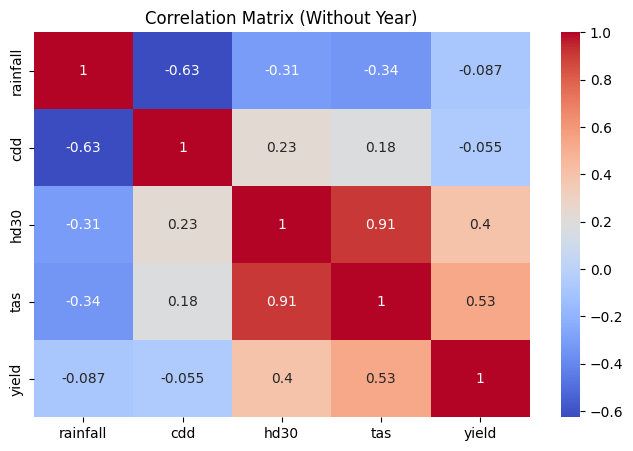


=== NORMALITY TEST (Shapiro-Wilk) ===
rainfall: p-value = 0.9226831683886106
cdd: p-value = 0.25818440406578724
hd30: p-value = 0.6890864033600733
tas: p-value = 0.6957164068609022
yield: p-value = 1.3044287287787298e-05


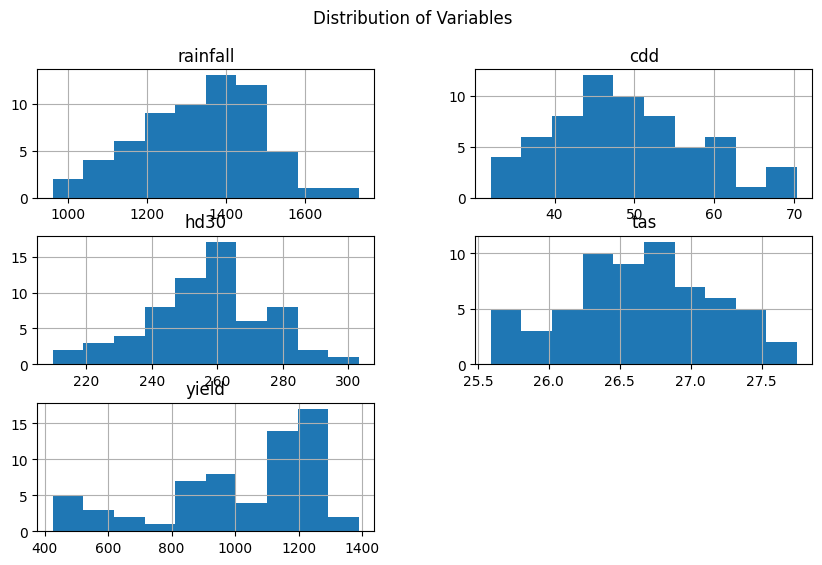

In [6]:
# STEP 3 — STATISTICAL ANALYSIS

import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro

# 1. Correlation 

corr = data.drop(columns=['year']).corr()

print("=== CORRELATION MATRIX ===")
print(corr)

# Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix (Without Year)")
plt.show()

# 2. Normality test (Shapiro)

print("\n=== NORMALITY TEST (Shapiro-Wilk) ===")

for col in ['rainfall', 'cdd', 'hd30', 'tas', 'yield']:
    stat, p = shapiro(data[col])
    print(f"{col}: p-value = {p}")

# 3. Distribution plots

data.drop(columns=['year']).hist(figsize=(10,6))
plt.suptitle("Distribution of Variables")
plt.show()

In [7]:
# MODEL 1 — CLIMATE ONLY

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Features based on correlation analysis
X = data[['tas', 'rainfall', 'cdd']]
y = data['yield']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("R2 climate only:", r2_score(y_test, pred))

R2 climate only: 0.08216966998144815


In [8]:
# MODEL 2 — ADD NONLINEARITY

# Add rainfall squared
data['rain_sq'] = data['rainfall'] ** 2

X = data[['tas', 'rainfall', 'rain_sq', 'cdd']]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("R2 climate + nonlinear:", r2_score(y_test, pred))

R2 climate + nonlinear: 0.10516435854721806


In [9]:
# MODEL 3 — ADD TREND

data['trend'] = data['year'] - 1960

X = data[['tas', 'rainfall', 'rain_sq', 'cdd', 'trend']]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("R2 climate + trend:", r2_score(y_test, pred))

R2 climate + trend: 0.750262699703623


In [10]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
print(importance)

tas         0.096410
rainfall    0.032447
rain_sq     0.026837
cdd         0.039998
trend       0.804308
dtype: float64


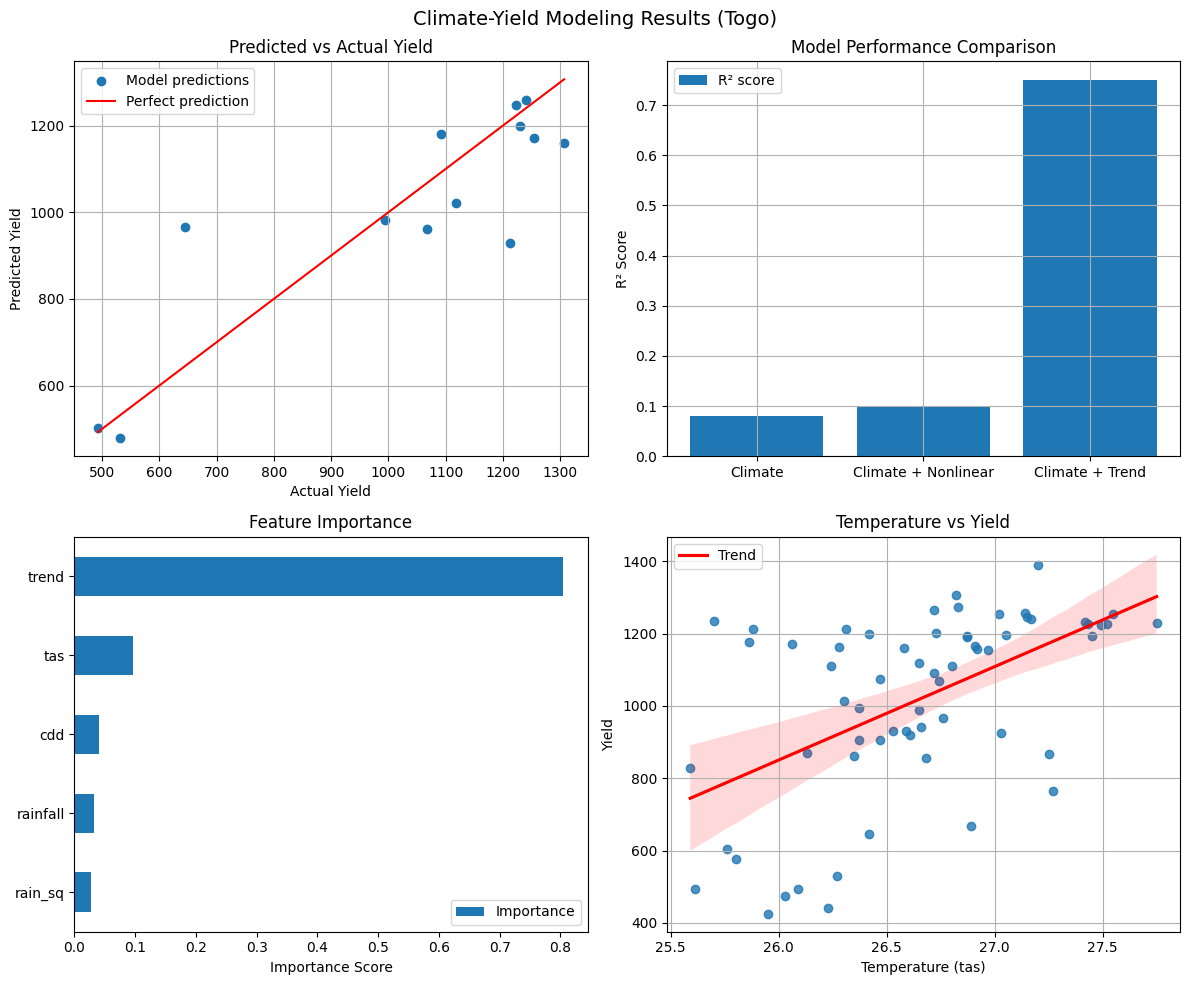

In [11]:
# COMMUNICATION FIGURE 

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12,10))

# 1. Predicted vs Actual
axes[0,0].scatter(y_test, pred, label="Model predictions")
axes[0,0].plot([y_test.min(), y_test.max()],
               [y_test.min(), y_test.max()],
               color='red', label="Perfect prediction")

axes[0,0].set_title("Predicted vs Actual Yield")
axes[0,0].set_xlabel("Actual Yield")
axes[0,0].set_ylabel("Predicted Yield")
axes[0,0].legend()
axes[0,0].grid()

# 2. Model Comparison

models = ['Climate', 'Climate + Nonlinear', 'Climate + Trend']
scores = [0.08, 0.10, 0.75]

axes[0,1].bar(models, scores, label="R² score")

axes[0,1].set_title("Model Performance Comparison")
axes[0,1].set_ylabel("R² Score")
axes[0,1].legend()
axes[0,1].grid()

# 3. Feature Importance

importance = pd.Series(model.feature_importances_, index=X.columns)

importance.sort_values().plot(kind='barh', ax=axes[1,0], label="Importance")

axes[1,0].set_title("Feature Importance")
axes[1,0].set_xlabel("Importance Score")
axes[1,0].legend()

# 4. Temperature vs Yield

sns.regplot(x='tas', y='yield', data=data, ax=axes[1,1],
            scatter_kws={'label': 'Data'},
            line_kws={'color': 'red', 'label': 'Trend'})

axes[1,1].set_title("Temperature vs Yield")
axes[1,1].set_xlabel("Temperature (tas)")
axes[1,1].set_ylabel("Yield")
axes[1,1].legend()
axes[1,1].grid()

# FINAL TOUCH

plt.suptitle("Climate-Yield Modeling Results (Togo)", fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
# CREATE STANDARDIZED INDEX

from sklearn.preprocessing import StandardScaler

# Select variables
features = data[['rainfall', 'tas', 'cdd']]

# Standardize
scaler = StandardScaler()
scaled = scaler.fit_transform(features)

# Create index (mean of standardized variables)
data['climate_index'] = scaled.mean(axis=1)

print(data[['climate_index']].head())

   climate_index
0      -0.422925
1      -0.015025
2      -0.254151
3      -0.604088
4      -0.370296


In [15]:
# MODEL WITH CLIMATE INDEX

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

X = data[['climate_index']]
y = data['yield']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("R2 climate index:", r2_score(y_test, pred))

R2 climate index: 0.20014179958427836


In [16]:
# PCA ANALYSIS

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Select climate variables
features = data[['rainfall', 'tas', 'cdd']]

# Standardize
scaler = StandardScaler()
scaled = scaler.fit_transform(features)

# Apply PCA
pca = PCA()
components = pca.fit_transform(scaled)

# Explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.59826263 0.28506076 0.11667661]


In [17]:
# Create principal components
data['PC1'] = components[:,0]
data['PC2'] = components[:,1]

print(data[['PC1','PC2']].head())

        PC1       PC2
0 -2.557887 -2.283616
1  0.139381 -2.020301
2  0.831140 -0.948039
3 -1.527885 -1.392050
4  0.137034 -1.402271


In [18]:
# MODEL WITH PCA

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

X = data[['PC1', 'PC2']]
y = data['yield']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("R2 PCA model:", r2_score(y_test, pred))

R2 PCA model: 0.5464515255944948


In [19]:
# PCA + TREND

data['trend'] = data['year'] - 1960

X = data[['PC1', 'PC2', 'trend']]
y = data['yield']

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Final R2 (PCA + trend):", r2_score(y_test, pred))

Final R2 (PCA + trend): 0.7869176938053916


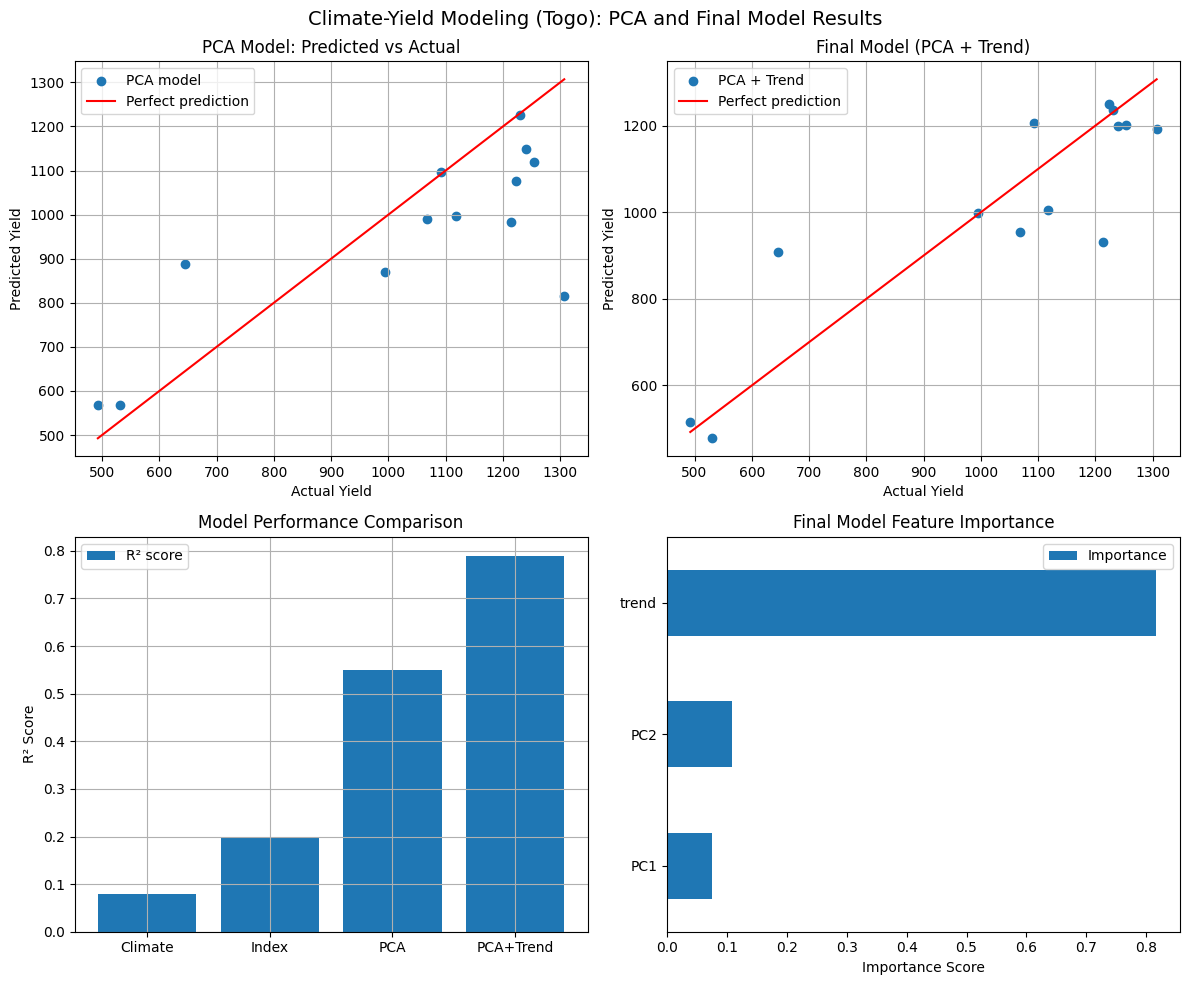

In [20]:
# FINAL COMMUNICATION FIGURE (PCA + FINAL MODEL)

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12,10))

# 1. PCA Model (Actual vs Predicted)
# Re-train PCA model for plotting
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_pca = data[['PC1', 'PC2']]
y = data['yield']

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

model_pca = RandomForestRegressor(random_state=42)
model_pca.fit(X_train_pca, y_train_pca)

pred_pca = model_pca.predict(X_test_pca)

axes[0,0].scatter(y_test_pca, pred_pca, label="PCA model")
axes[0,0].plot([y_test_pca.min(), y_test_pca.max()],
               [y_test_pca.min(), y_test_pca.max()],
               color='red', label="Perfect prediction")

axes[0,0].set_title("PCA Model: Predicted vs Actual")
axes[0,0].set_xlabel("Actual Yield")
axes[0,0].set_ylabel("Predicted Yield")
axes[0,0].legend()
axes[0,0].grid()

# 2. FINAL MODEL (PCA + Trend)

data['trend'] = data['year'] - 1960

X_final = data[['PC1', 'PC2', 'trend']]

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_final, y, test_size=0.2, random_state=42
)

model_final = RandomForestRegressor(random_state=42)
model_final.fit(X_train_f, y_train_f)

pred_final = model_final.predict(X_test_f)

axes[0,1].scatter(y_test_f, pred_final, label="PCA + Trend")
axes[0,1].plot([y_test_f.min(), y_test_f.max()],
               [y_test_f.min(), y_test_f.max()],
               color='red', label="Perfect prediction")

axes[0,1].set_title("Final Model (PCA + Trend)")
axes[0,1].set_xlabel("Actual Yield")
axes[0,1].set_ylabel("Predicted Yield")
axes[0,1].legend()
axes[0,1].grid()

# 3. MODEL COMPARISON

models = ['Climate', 'Index', 'PCA', 'PCA+Trend']
scores = [0.08, 0.20, 0.55, 0.79]

axes[1,0].bar(models, scores, label="R² score")

axes[1,0].set_title("Model Performance Comparison")
axes[1,0].set_ylabel("R² Score")
axes[1,0].legend()
axes[1,0].grid()

# 4. FINAL FEATURE IMPORTANCE

importance = pd.Series(model_final.feature_importances_, index=X_final.columns)

importance.sort_values().plot(kind='barh', ax=axes[1,1], label="Importance")

axes[1,1].set_title("Final Model Feature Importance")
axes[1,1].set_xlabel("Importance Score")
axes[1,1].legend()

# FINAL TOUCH

plt.suptitle("Climate-Yield Modeling (Togo): PCA and Final Model Results", fontsize=14)
plt.tight_layout()
plt.show()